<div 
  <h1 style='text-align: center; background: #c102 color: #442988; font-family: Serif, sans-serif; margin: 0 0 6px 0; font-size: 1.8em;'>بِسْمِ اللهِ الرَّحْمٰنِ الرَّحِيْمِ</h1>
</div>

<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Medical Cost Prediction</h1>
<h2 <h2 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Feature Selection & Model Optimization</h2>
</div>


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pickle
import warnings
import math
warnings.filterwarnings('ignore')

path = r"C:\Users\Qasim Ashfaq\Desktop\1010\medical_cost_prediction_dataset.csv"
data = pd.read_csv(path)
print('Dataset shape:', data.shape)
data.head()

Dataset shape: (5000, 20)


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Data Exploration</h1>
</div>

In [37]:
print("*** Basic Info ***")
data.info()
print("\n*** Null Values ***")
print(data.isnull().sum())
print("\n*** Target Column (annual_medical_cost) ***")
print(data["annual_medical_cost"].describe())

*** Basic Info ***
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   str    
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   str    
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   str    
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count

The Insurance Type Column Has 1048 Null Values !

<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Data Cleaning</h1>
</div>

In [38]:

data['insurance_type'] = data['insurance_type'].fillna(data['insurance_type'].mode()[0])

print('Nulls after cleaning:', data.isnull().sum())  

Nulls after cleaning: age                        0
gender                     0
bmi                        0
smoker                     0
diabetes                   0
hypertension               0
heart_disease              0
asthma                     0
physical_activity_level    0
daily_steps                0
sleep_hours                0
stress_level               0
doctor_visits_per_year     0
hospital_admissions        0
medication_count           0
insurance_type             0
insurance_coverage_pct     0
city_type                  0
previous_year_cost         0
annual_medical_cost        0
dtype: int64


<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Label Encoding</h1>
</div>

In [39]:
le = LabelEncoder()


encoders = {}
category_columns = ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type']

for col in category_columns:
    enc = LabelEncoder()
    data[col] = enc.fit_transform(data[col].astype(str))
    encoders[col] = enc
    print(f'{col}: {list(enc.classes_)}')

data.head()

gender: ['Female', 'Male']
smoker: ['No', 'Yes']
physical_activity_level: ['High', 'Low', 'Medium']
insurance_type: ['Government', 'Private']
city_type: ['Rural', 'Semi-Urban', 'Urban']


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,1,29.4,0,1,0,0,0,2,14825,4.4,8,1,0,4,1,80,1,10885,2645.50
1,32,0,22.9,0,1,0,0,0,2,3620,6.0,7,4,3,0,0,64,1,18722,10959.70
2,89,1,25.7,0,0,0,0,0,0,10578,4.5,7,2,0,3,1,0,2,4196,8409.80
3,78,1,31.9,1,0,1,0,0,1,6226,8.6,9,6,1,7,0,70,2,11128,7996.62
4,38,1,27.7,0,0,0,0,0,0,6253,5.7,3,6,0,6,1,77,2,15110,3202.52


#### We save the encoder for each column so Streamlit can use it later

<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Feature Correlation Analysis</h1>
<h3 <h3 style="text-align: left;font-family : Serif; background : #c012; color: #3566ae";>We check which features actually correlate with `annual_medical_cost` before training.</h3>
</div>







In [40]:
feature_columns = [c for c in data.columns if c != 'annual_medical_cost']

corr = data[feature_columns + ['annual_medical_cost']].corr()['annual_medical_cost'].drop('annual_medical_cost')
corr_sorted = corr.abs().sort_values(ascending=False)

print('Sorted Feature correlations with annual_medical_cost in Descending Order')
print(corr_sorted.to_string())

Sorted Feature correlations with annual_medical_cost in Descending Order
insurance_coverage_pct     0.856152
hospital_admissions        0.355629
insurance_type             0.143667
medication_count           0.133298
heart_disease              0.121740
previous_year_cost         0.089275
smoker                     0.061673
diabetes                   0.051429
hypertension               0.046926
doctor_visits_per_year     0.033748
bmi                        0.031030
age                        0.025330
stress_level               0.012596
gender                     0.012557
city_type                  0.011098
asthma                     0.008869
physical_activity_level    0.006690
sleep_hours                0.004788
daily_steps                0.001819


Lets Visualize the Most Corelated Features with Our Target, that is Annual Cost

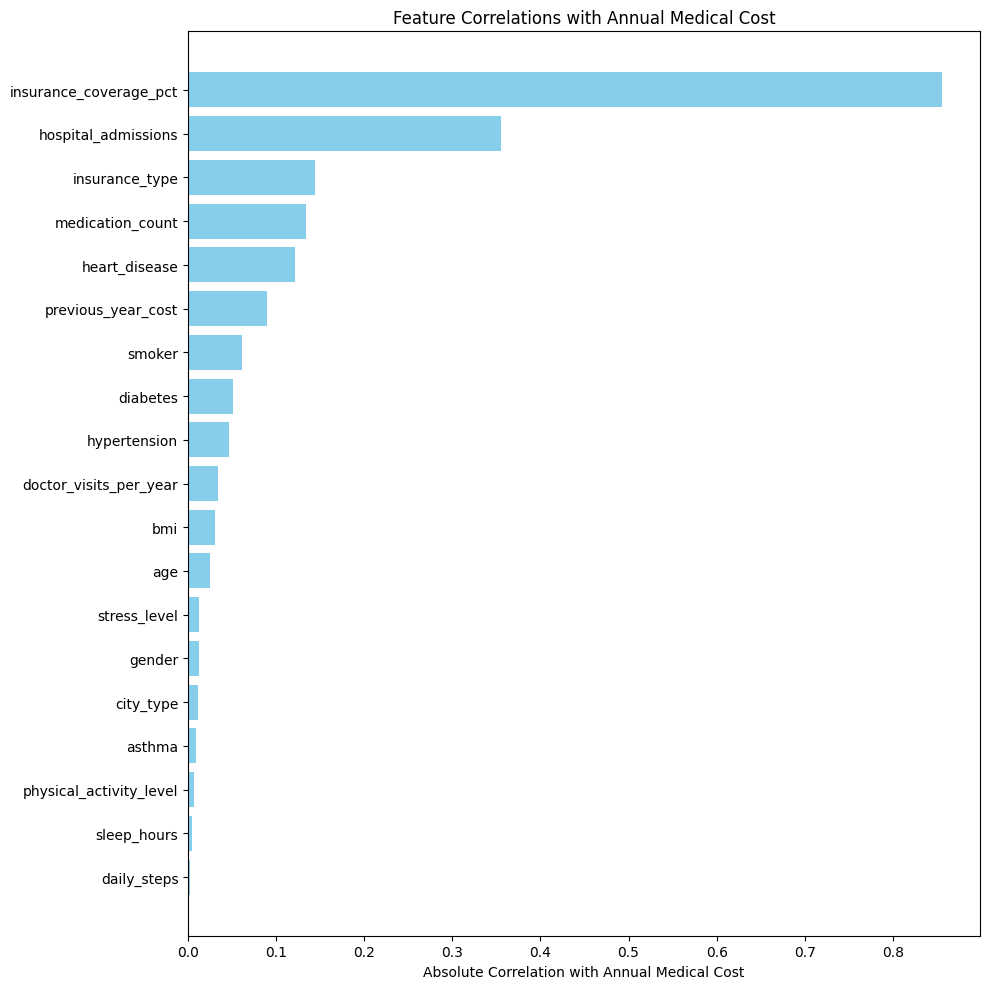

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.barh(corr_sorted.index[::-1], corr_sorted.values[::-1], color='skyblue')
plt.xlabel('Absolute Correlation with Annual Medical Cost')
plt.title('Feature Correlations with Annual Medical Cost')
plt.tight_layout()
plt.show()


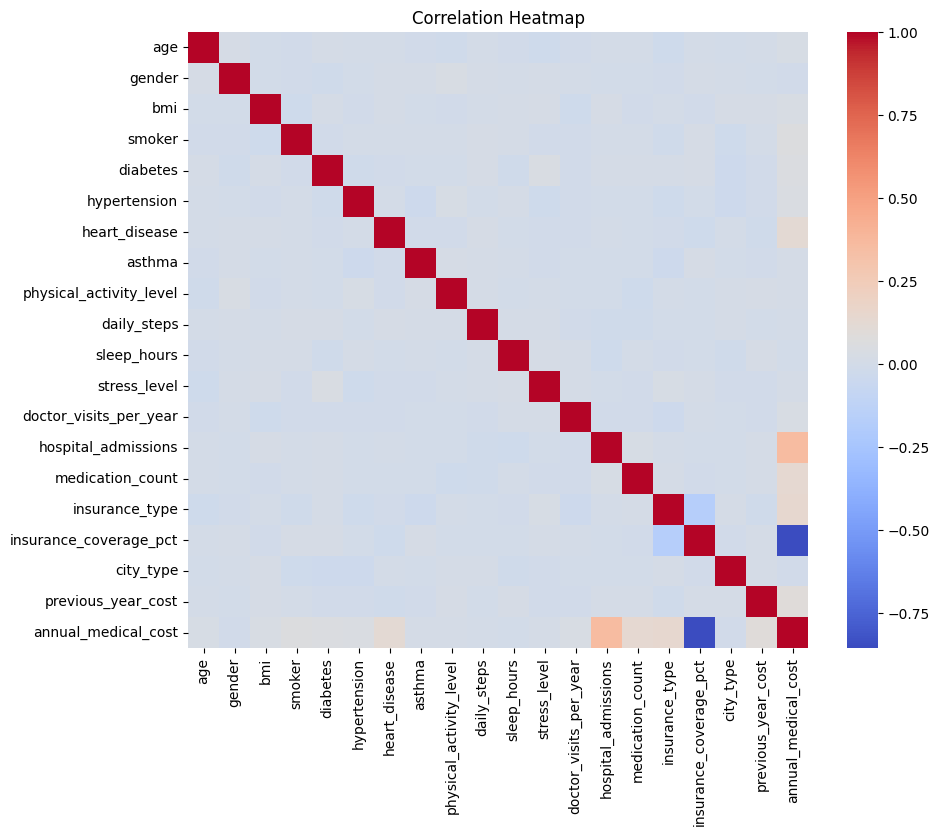

In [ ]:
#corelation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), )
plt.title('Correlation Heatmap')
plt.show()



<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Selecting Best Features</h1>
</div> 


In [42]:
best_features = [
    'insurance_coverage_pct',
    'hospital_admissions',
    'insurance_type',
    'medication_count',
    'heart_disease',
    'previous_year_cost',
    'smoker',
    'diabetes',
    'hypertension',
    'doctor_visits_per_year',
    'bmi',
    'age'
]

X = data[best_features]
y = data['annual_medical_cost']
count = 0
for i in best_features:
    count+=1
    print(f"{count}: {i}")
print('X shape:', X.shape)

1: insurance_coverage_pct
2: hospital_admissions
3: insurance_type
4: medication_count
5: heart_disease
6: previous_year_cost
7: smoker
8: diabetes
9: hypertension
10: doctor_visits_per_year
11: bmi
12: age
X shape: (5000, 12)


<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Train Test Split</h1>
</div>

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)
print("Done Train Test Splitting !")

Done Train Test Splitting !


<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Training the Model</h1>
<h3 <h3 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Using *Gradient Boosting* Technique</h3>
<h4 <h4 style="text-align: left;font-family : Serif; background : #c012; color: #3566ae";>It builds many small trees, each Tree correcting the mistakes of the previous one.</h4>
</div>

In [44]:
model = GradientBoostingRegressor(
    n_estimators=300,    
    learning_rate=0.05,  
    max_depth=5,         
    random_state=55
)

model.fit(X_train, y_train)
print('Model trained!')

Model trained!


<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Testing the Model Accuracy</h1>
</div>


In [65]:
y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error
r2   = r2_score(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test, y_pred)
print("*** Test Results ***")
print(f"R² Score : {round(r2*100,2)}% ")
print(f"RMSE: ${rmse}")
print(f"MAE: ${mae}")

*** Test Results ***
R² Score : 99.3% 
RMSE: $624.0520256769474
MAE: $373.1480379141304


<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Plotting Actual vs Predicted Graph</h1>
</div>


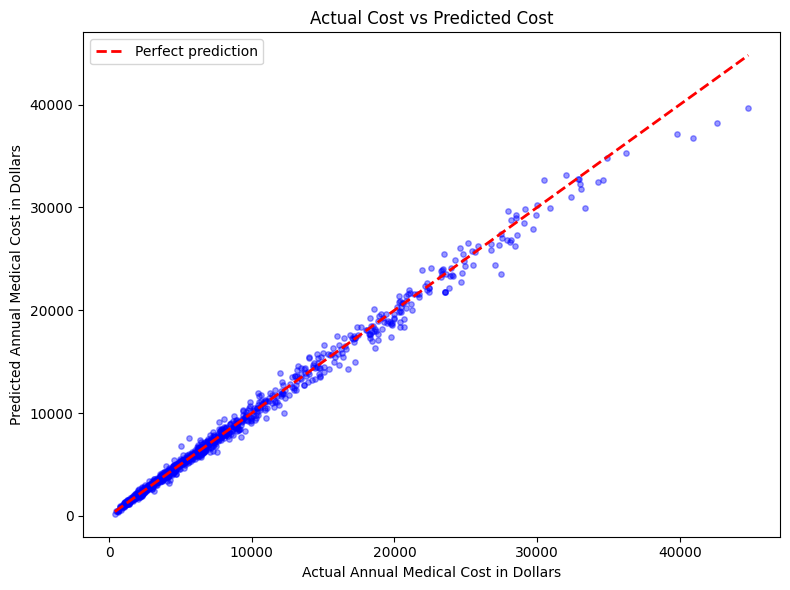

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Annual Medical Cost in Dollars')
plt.ylabel('Predicted Annual Medical Cost in Dollars')
plt.title('Actual Cost vs Predicted Cost')
plt.legend()
plt.tight_layout()
plt.show()

<div>
<h1 <h1 style="text-align: center;font-family : Serif; background : #c012; color: #3566ae";>Saving the Model</h1>
</div>

We save the model so that it dosent always start training from the beginning as it will consume much time.

In [47]:
save_path = r"C:/Users/Qasim Ashfaq/Desktop/1010/"

with open(save_path + 'model_medical_cost.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'features': best_features,
        'encoders': encoders
                }, f)

print("Model is saved as model_medical_cost.pkl")


Model is saved as model_medical_cost.pkl


<div 
  <h1 style='text-align: center; background: #c102 color: #442988; font-family: Serif, sans-serif; margin: 0 0 6px 0; font-size: 1.8em;'>ٱلْحَمْدُ لِلَّٰهِ</h1> 
  <h2 style="text-align : center ; background: #c102 ; color:#442988 ;font-family : Serif;font-size:1.3em;">Praise be To Allah</h2>
</div>